# Forex currency forecasting

My notebook uses the reusable project pipeline and a CSV file:


In [19]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from forex_pipeline import (currency_columns, evaluate_models, load_forex_data, train_artifact, forecast_artifact)


## Load and preprocess

The loader removes unnamed columns, parses `dd-mm-yyyy` dates to convert them into a useful format, turns invalid numeric placeholders to missing values, and sorts the indexes in order, while using time interpolation followed by edge filling to deal with empty entries.


In [20]:
data = load_forex_data()
data.head(), data.shape, data.isna().sum().sum()


(            AUSTRALIA - AUSTRALIAN DOLLAR/US$  EURO AREA - EURO/US$  \
 Time Serie                                                            
 2000-01-03                             1.5172                0.9847   
 2000-01-04                             1.5239                0.9700   
 2000-01-05                             1.5267                0.9676   
 2000-01-06                             1.5291                0.9686   
 2000-01-07                             1.5272                0.9714   
 
             NEW ZEALAND - NEW ZELAND DOLLAR/US$  \
 Time Serie                                        
 2000-01-03                               1.9033   
 2000-01-04                               1.9238   
 2000-01-05                               1.9339   
 2000-01-06                               1.9436   
 2000-01-07                               1.9380   
 
             UNITED KINGDOM - UNITED KINGDOM POUND/US$  BRAZIL - REAL/US$  \
 Time Serie                                        

## Exploratory analysis
selected_currency can be changed in order to analyse another currency such as Japanese Yen or Pound Sterling.

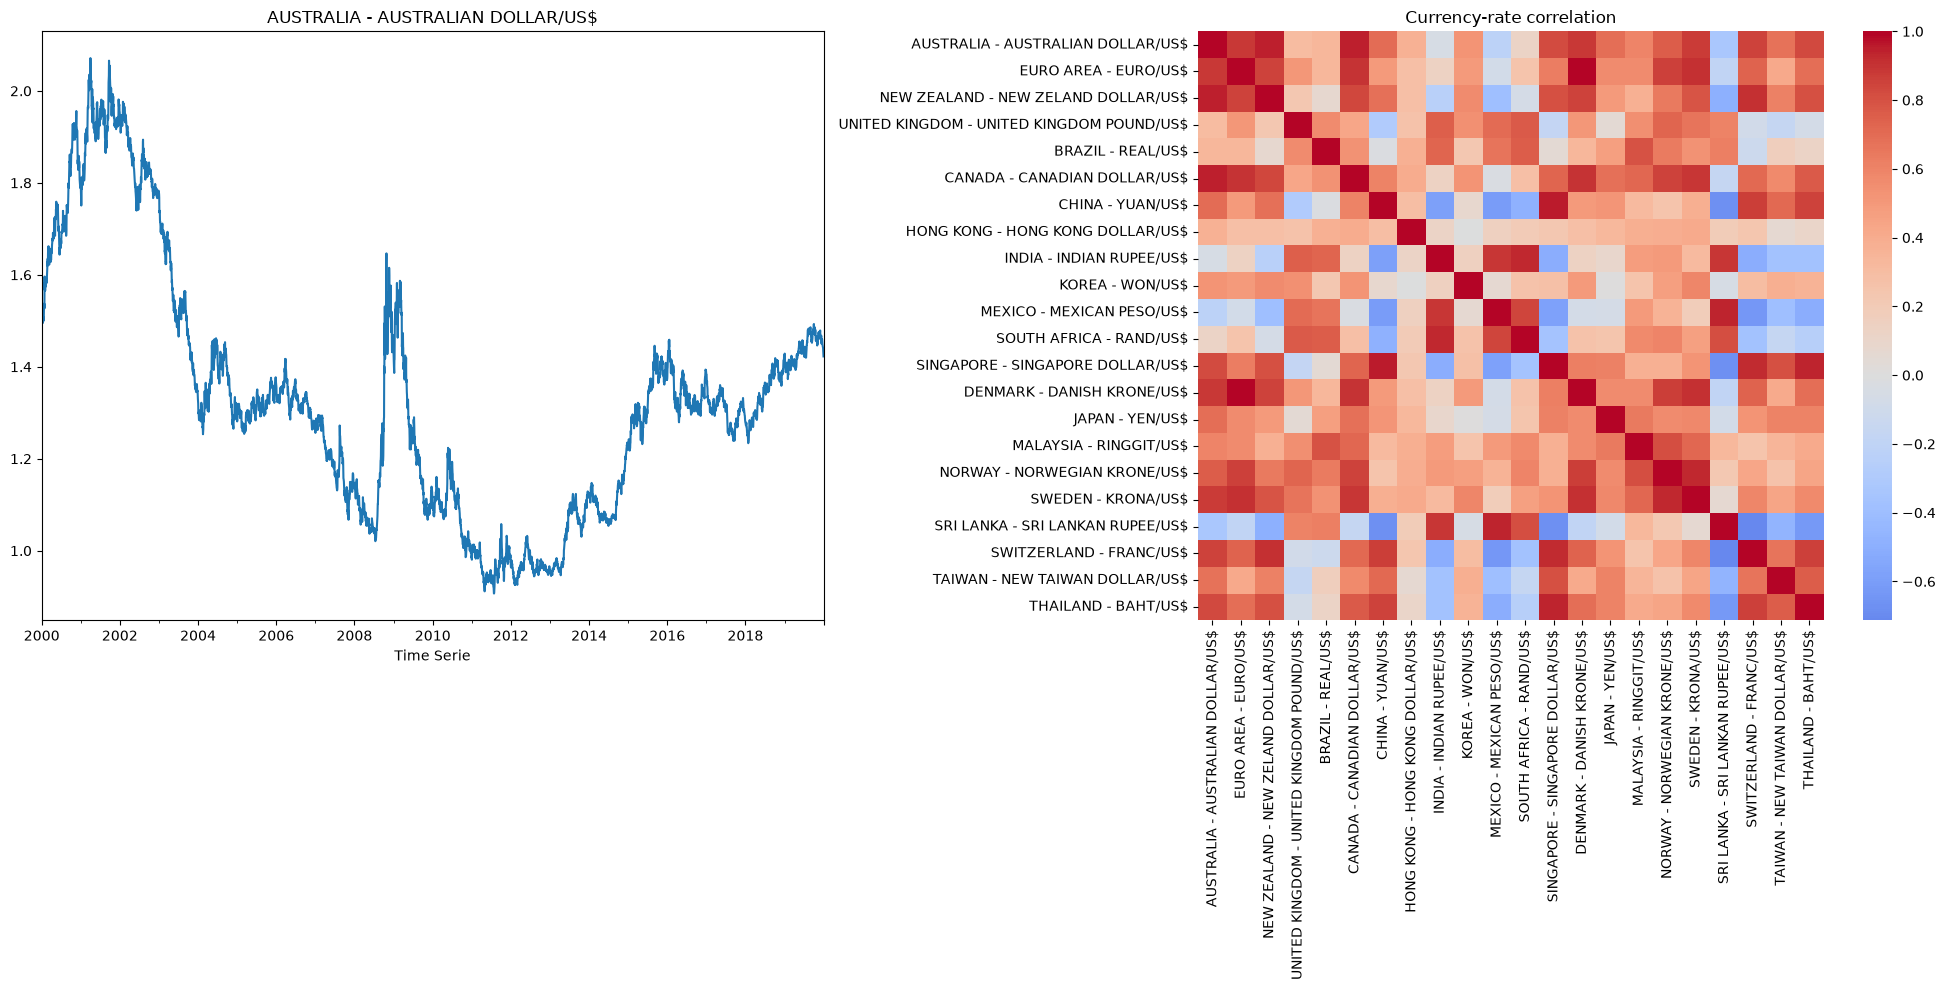

In [23]:
selected_currency = 'AUSTRALIA - AUSTRALIAN DOLLAR/US$'
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
data[selected_currency].plot(ax=axes[0], title=selected_currency)
sns.heatmap(data[currency_columns(data)].corr(), cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Currency-rate correlation')
plt.tight_layout()


## Holdout comparison

The final 60 observations are held out for training purposes. Each series compares a persistence baseline (i.e next value matches previous) with a lagged Ridge model using 1, 5, and 20-day lags plus weekly and yearly cyclic features as patterns. Metrics I used to measure accuracy are MAE, RMSE, and MAPE.


In [ ]:
results, best_model = evaluate_models(data[selected_currency])
results


## Save the selected model

Run the project script to train and save all 22 currencies. This cell shows the exact single-currency serialization used by that script.


In [ ]:
Path('models').mkdir(exist_ok=True)
artifact = train_artifact(data[selected_currency], best_model)
artifact['currency'] = selected_currency
model_path = Path('models') / f"{selected_currency.replace('/', '_')}.joblib"
joblib.dump(artifact, model_path)
forecast_artifact(artifact, horizon=30).head()


To build the complete model set for the Streamlit app, run `python train_models.py` from the project root.
